In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
import warnings
warnings.filterwarnings("ignore")

In [9]:
import os
source = "/Users/hades/Desktop/Bruchas Lab/Encoder_Decoder/DJM_binary_classification/Relate_Terminal_to_NAc/signal_data"
files = sorted([f for f in os.listdir(source) if f.endswith(".npy")])
full_paths = [os.path.join(source, f) for f in files]
np_arrs = [np.load(f) for f in full_paths]

stacked_arrs = np.stack(np_arrs, axis=1)

nac1 = np_arrs[0]
nac2 = np_arrs[1]
nac3 = np_arrs[2]
nac4 = np_arrs[3]
nac5 = np_arrs[4]
terminal = np_arrs[5]

clusters = [
    nac1,
    nac2,
    nac3,
    nac4,
    nac5
]

In [10]:
activities_df = pd.DataFrame(stacked_arrs, index=range(699), columns=['NAc 1', 'NAc 2', 'NAc 3', 'NAc 4', 'NAc 5', 'Terminal'])
activities_df.head()

,NAc 1,NAc 2,NAc 3,NAc 4,NAc 5,Terminal
0,-0.021607,0.434483,0.177145,0.417304,0.405744,-0.012750
1,-0.031841,0.284070,0.151285,0.335453,0.367546,-0.012125
2,0.157118,0.372031,0.001853,0.250073,0.374618,-0.012294
3,0.187725,0.360902,-0.148249,0.216329,0.201273,-0.024266
4,0.159344,0.217029,-0.226570,-0.010079,0.164621,-0.036238


In [16]:
def lag_plots(data_df):
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    lag_plot(data_df[data_df.columns[0]], ax=ax1)
    ax1.set_title(data_df.columns[0]);

    lag_plot(data_df[data_df.columns[1]], ax=ax2)
    ax2.set_title(data_df.columns[1]);

    ax1.set_ylabel('$y_{t+1}$');
    ax1.set_xlabel('$y_t$');
    ax2.set_ylabel('$y_{t+1}$');
    ax2.set_xlabel('$y_t$');

    plt.tight_layout()

def kpss_test(data_df):
    test_stat, p_val = [], []
    cv_1pct, cv_2p5pct, cv_5pct, cv_10pct = [], [], [], []
    for c in data_df.columns: 
        kpss_res = kpss(data_df[c].dropna(), regression='ct')
        test_stat.append(kpss_res[0])
        p_val.append(kpss_res[1])
        cv_1pct.append(kpss_res[3]['1%'])
        cv_2p5pct.append(kpss_res[3]['2.5%'])
        cv_5pct.append(kpss_res[3]['5%'])
        cv_10pct.append(kpss_res[3]['10%'])
    kpss_res_df = pd.DataFrame({'Test statistic': test_stat, 
                               'p-value': p_val, 
                               'Critical value - 1%': cv_1pct,
                               'Critical value - 2.5%': cv_2p5pct,
                               'Critical value - 5%': cv_5pct,
                               'Critical value - 10%': cv_10pct}, 
                             index=data_df.columns).T
    kpss_res_df = kpss_res_df.round(4)
    return kpss_res_df

def adf_test(data_df):
    test_stat, p_val = [], []
    cv_1pct, cv_5pct, cv_10pct = [], [], []
    for c in data_df.columns: 
        adf_res = adfuller(data_df[c].dropna())
        test_stat.append(adf_res[0])
        p_val.append(adf_res[1])
        cv_1pct.append(adf_res[4]['1%'])
        cv_5pct.append(adf_res[4]['5%'])
        cv_10pct.append(adf_res[4]['10%'])
    adf_res_df = pd.DataFrame({'Test statistic': test_stat, 
                               'p-value': p_val, 
                               'Critical value - 1%': cv_1pct,
                               'Critical value - 5%': cv_5pct,
                               'Critical value - 10%': cv_10pct}, 
                             index=data_df.columns).T
    adf_res_df = adf_res_df.round(4)
    return adf_res_df

In [12]:
clusters_to_terminal = [activities_df[[f'NAc {i}', 'Terminal']] for i in range(1, 6)]


Cluster 0
KPSS
                        NAc 1  Terminal
Test statistic         0.8004    0.4065
p-value                0.0100    0.0100
Critical value - 1%    0.2160    0.2160
Critical value - 2.5%  0.1760    0.1760
Critical value - 5%    0.1460    0.1460
Critical value - 10%   0.1190    0.1190

ADF
                       NAc 1  Terminal
Test statistic       -2.1117   -1.6633
p-value               0.2398    0.4501
Critical value - 1%  -3.4398   -3.4400
Critical value - 5%  -2.8657   -2.8658
Critical value - 10% -2.5690   -2.5690

Cluster 1
KPSS
                        NAc 2  Terminal
Test statistic         0.1882    0.4065
p-value                0.0204    0.0100
Critical value - 1%    0.2160    0.2160
Critical value - 2.5%  0.1760    0.1760
Critical value - 5%    0.1460    0.1460
Critical value - 10%   0.1190    0.1190

ADF
                       NAc 2  Terminal
Test statistic       -2.0575   -1.6633
p-value               0.2619    0.4501
Critical value - 1%  -3.4398   -3.4400
Critical

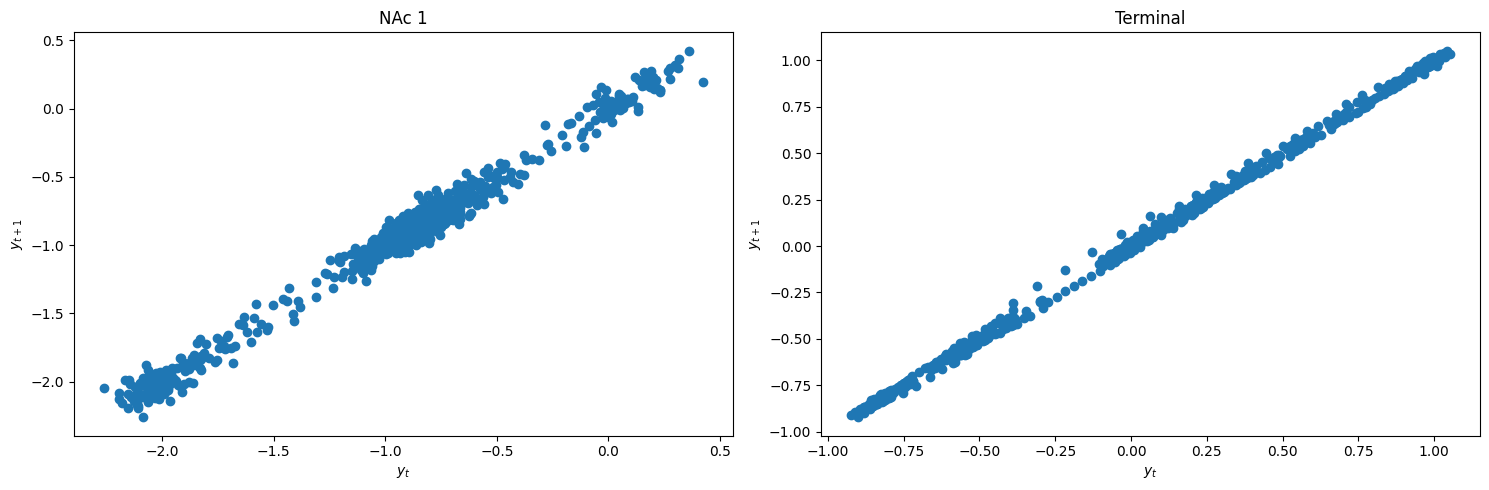

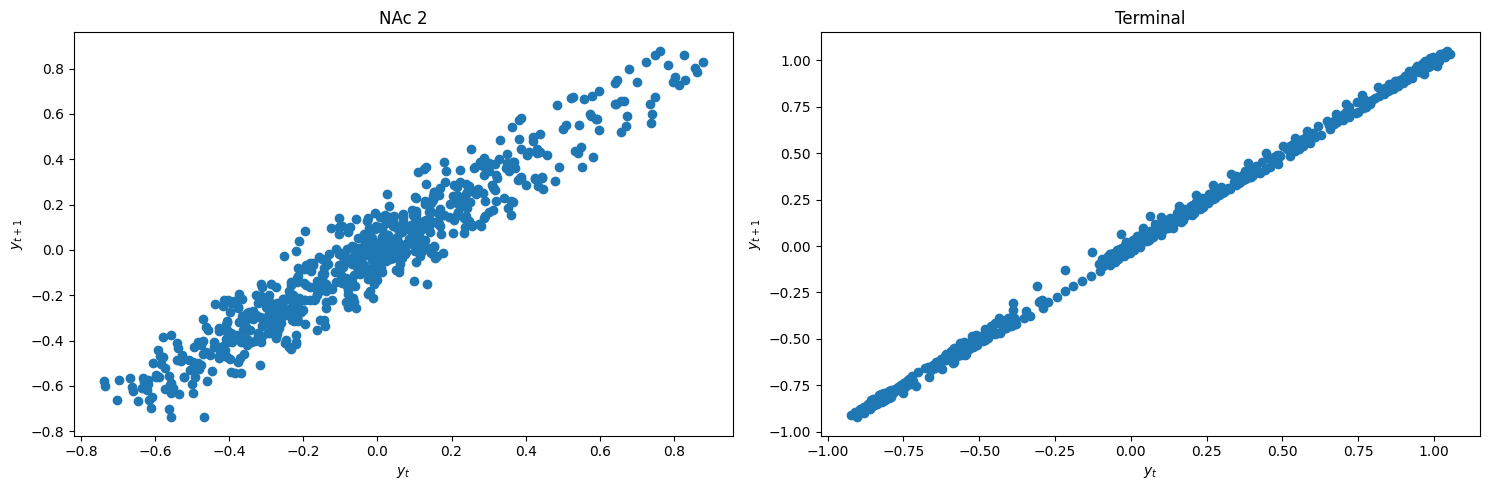

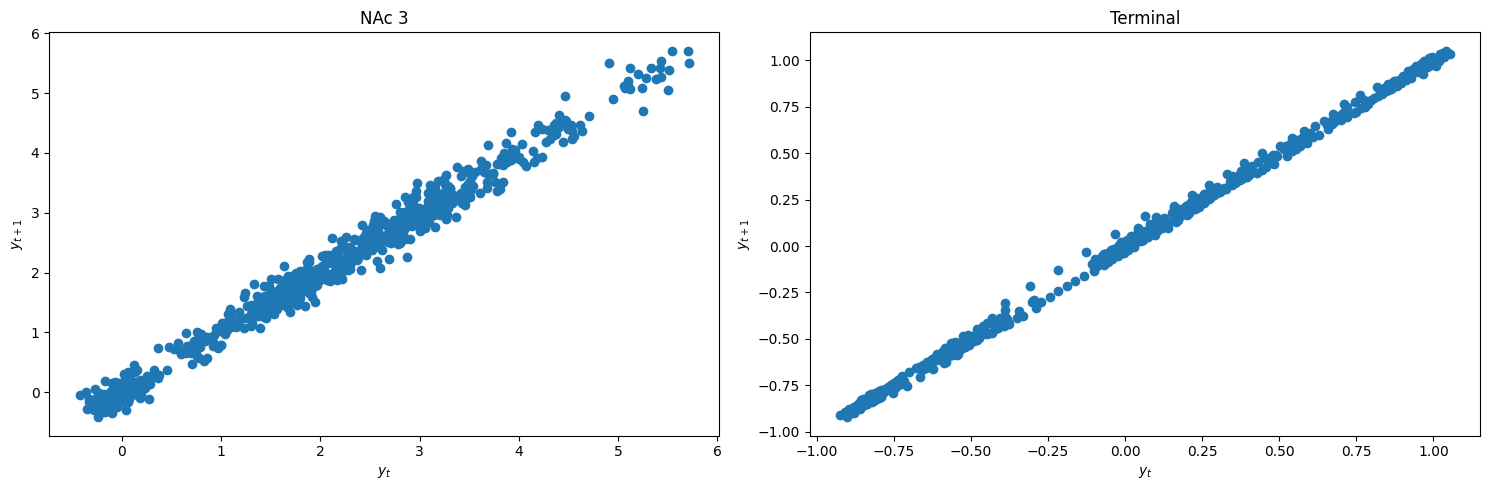

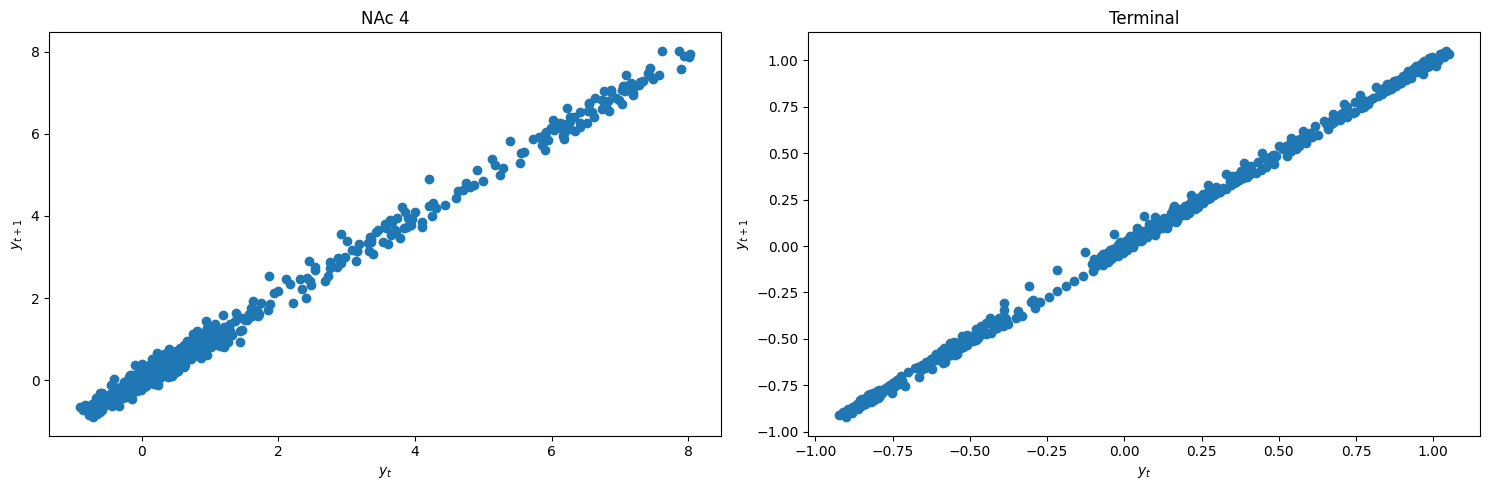

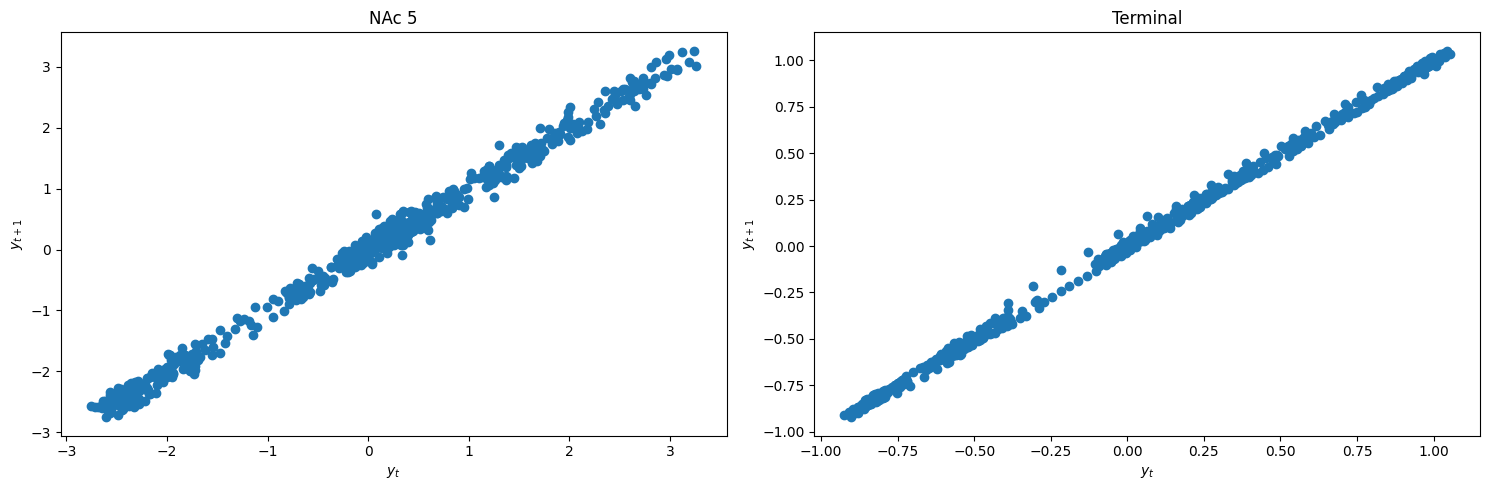

In [19]:
for i in range(5):
    data = clusters_to_terminal[i]
    print(f"\nCluster {i}")
    lag_plots(data)
    print("KPSS")
    print(kpss_test(data))
    print("\nADF")
    print(adf_test(data))

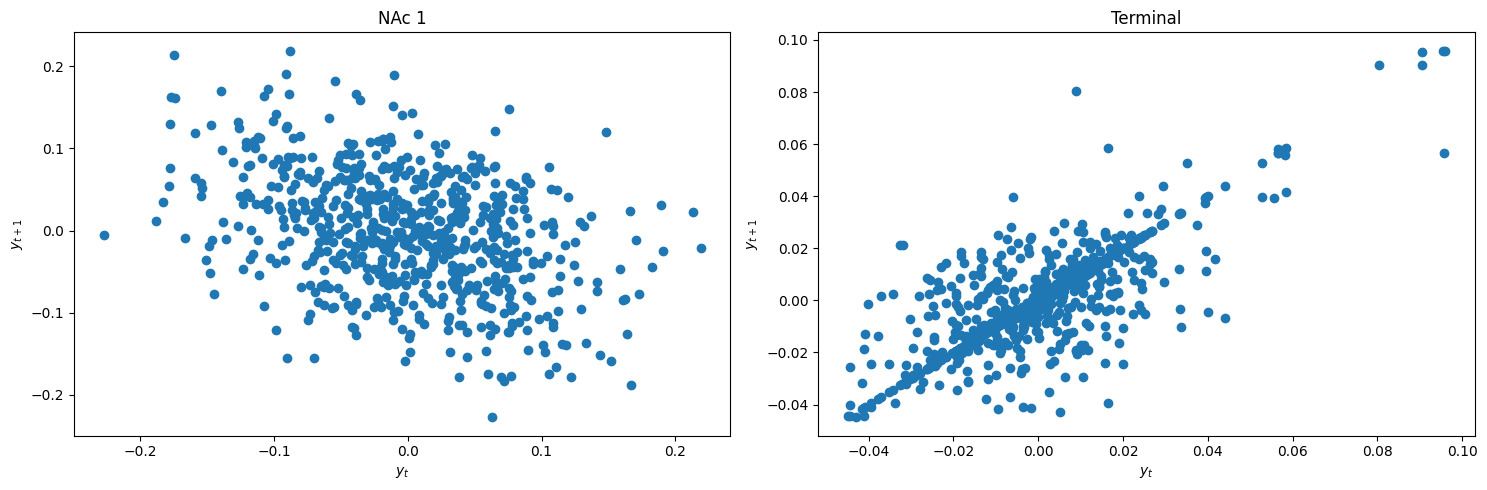

In [30]:
nac1_var = clusters_to_terminal[0].copy()
nac1_var = nac1_var - nac1_var.shift(1)
nac1_var = nac1_var.dropna()
lag_plots(nac1_var)